# A Small Two-Stage Production Plan

A plant chooses regular production before demand is known. After demand is observed, it may use expensive emergency production or dispose of surplus inventory.

This example is deliberately small enough to inspect by hand before studying larger stochastic programs.
**Prepared by:** Optimization for Decision Science course team (2026).


```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 7 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

## Step 0: Problem statement

Choose production before demand, then cover shortages or dispose of surplus.

### Learning goals

* Separate first-stage production from scenario-dependent recourse.
* Put recourse variables and constraints in scenario `Block`s.
* Check scenario probabilities and balance equations.
* Compute RP, EEV, WS, VSS, and EVPI.
* Interpret a capacity-sensitivity calculation.

In [1]:
# Install course dependencies before importing Pyomo on Colab.
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper

helper.set_plotting_style()

import matplotlib.pyplot as plt
import pandas as pd
import pyomo.environ as pyo

PRODUCTS = ["A", "B"]
SCENARIOS = ["low", "likely", "high"]
PROBABILITY = {"low": 0.25, "likely": 0.50, "high": 0.25}
DEMAND = {
    ("low", "A"): 20,
    ("low", "B"): 25,
    ("likely", "A"): 35,
    ("likely", "B"): 40,
    ("high", "A"): 60,
    ("high", "B"): 70,
}
REGULAR_COST = {"A": 20, "B": 28}
EMERGENCY_COST = {"A": 55, "B": 65}
DISPOSAL_COST = {"A": 4, "B": 6}
HOURS = {"A": 2, "B": 1}
CAPACITY = 100

assert abs(sum(PROBABILITY.values()) - 1) < 1e-12
assert all(EMERGENCY_COST[p] > REGULAR_COST[p] for p in PRODUCTS)
SOLVER = pyo.SolverFactory("appsi_highs")
assert SOLVER.available(
    exception_flag=False
), "Install HiGHS before running this notebook."

## Step 1: Mathematical model

Regular production $x_p$ is shared across scenarios. In scenario $s$, emergency production $e_{sp}$ and disposal $w_{sp}$ satisfy

$$x_p + e_{sp} - w_{sp} = d_{sp}.$$

The objective minimizes regular cost plus expected recourse cost. Positive regular and disposal costs make production solely for disposal unattractive. A shared plan can still leave surplus in a low-demand scenario. These are illustrative data, not an empirical plant calibration.
## Step 2: Degree of freedom analysis

**Units and model size.** Costs are dollars per product unit; regular capacity is hours. There are 2 shared production variables and 12 recourse variables, 6 independent product balances, and one capacity inequality: 8 degrees of freedom before active inequalities. Bounds are not equality constraints.

`build_model(demand, probability, capacity)` returns a fresh Pyomo model. The arguments give scenario/product demand [units], scenario probabilities, and regular capacity [hours]; other illustrative cost data are fixed above.


## Step 3: Pyomo implementation


In [2]:
def build_model(demand=DEMAND, probability=PROBABILITY, capacity=CAPACITY):
    """Build a two-stage LP with product quantities in units.

    Args: demand [units], probability [fraction], capacity [hours].
    Returns: a fresh Pyomo ConcreteModel, ready to solve.
    """
    m = pyo.ConcreteModel()
    m.P = pyo.Set(initialize=PRODUCTS, ordered=True)
    m.S = pyo.Set(initialize=list(probability), ordered=True)
    m.probability = pyo.Param(m.S, initialize=probability)
    # One shared plan: production cannot anticipate realized demand.
    m.regular = pyo.Var(m.P, domain=pyo.NonNegativeReals)

    # Hours/unit times units cannot exceed available regular hours.
    @m.Constraint()
    def capacity_limit(b):
        return sum(HOURS[p] * b.regular[p] for p in b.P) <= capacity

    # The rule below adds emergency production and disposal per scenario.
    m.scenario = pyo.Block(m.S, rule=lambda b, s: add_scenario(b, s, m, demand))
    m.regular_cost = pyo.Expression(
        expr=sum(REGULAR_COST[p] * m.regular[p] for p in m.P)
    )
    # Pay first-stage cost once; probability-weight only recourse costs.
    m.expected_recourse_cost = pyo.Expression(
        expr=sum(m.probability[s] * m.scenario[s].recourse_cost for s in m.S)
    )
    m.objective = pyo.Objective(
        expr=m.regular_cost + m.expected_recourse_cost, sense=pyo.minimize
    )
    return m

In [3]:
def add_scenario(block, scenario, m, demand):
    """Attach one scenario's recourse; emergency capacity is unlimited."""
    block.emergency = pyo.Var(m.P, domain=pyo.NonNegativeReals)
    block.disposal = pyo.Var(m.P, domain=pyo.NonNegativeReals)

    # Emergency supply covers shortages; disposal removes surplus.
    # Every block refers to the same root regular-production variables.
    @block.Constraint(m.P)
    def balance(b, p):
        return m.regular[p] + b.emergency[p] - b.disposal[p] == demand[scenario, p]

    # Costs are dollars/unit, giving dollars for this realization.
    block.recourse_cost = pyo.Expression(
        expr=sum(
            EMERGENCY_COST[p] * block.emergency[p]
            + DISPOSAL_COST[p] * block.disposal[p]
            for p in m.P
        )
    )

## Step 4: Analyze results


In [4]:
def solve(model):
    result = SOLVER.solve(model)
    assert pyo.check_optimal_termination(result), result.solver.termination_condition
    return model


def regular_plan(model):
    return {p: float(pyo.value(model.regular[p])) for p in model.P}


recourse_model = solve(build_model())
print("regular plan:", regular_plan(recourse_model))
print("expected cost:", round(pyo.value(recourse_model.objective), 2))

regular plan: {'A': 30.0, 'B': 40.0}
expected cost: 2790.0


## Inspect every scenario

Do not trust the objective alone. Verify that every scenario balances and that recourse responds in the expected direction.

In [5]:
rows = []
for s in recourse_model.S:
    block = recourse_model.scenario[s]
    for p in recourse_model.P:
        regular = pyo.value(recourse_model.regular[p])
        emergency = pyo.value(block.emergency[p])
        disposal = pyo.value(block.disposal[p])
        residual = regular + emergency - disposal - DEMAND[s, p]
        assert abs(residual) <= 1e-7
        rows.append(
            {
                "scenario": s,
                "product": p,
                "regular": regular,
                "emergency": emergency,
                "disposal": disposal,
                "demand": DEMAND[s, p],
            }
        )
pd.DataFrame(rows).set_index(["scenario", "product"]).round(2)

regular  emergency  disposal  demand
scenario product                                      
low      A           30.0        0.0      10.0      20
         B           40.0        0.0      15.0      25
likely   A           30.0        5.0       0.0      35
         B           40.0        0.0       0.0      40
high     A           30.0       30.0       0.0      60
         B           40.0       30.0       0.0      70

## Value of stochastic and perfect information

For this minimization problem:

* **RP** is the optimal two-stage expected cost.
* **EEV** evaluates the mean-demand plan across all scenarios.
* **WS** averages independent perfect-information plans.
* $\mathrm{VSS}=EEV-RP$.
* $\mathrm{EVPI}=RP-WS$.

Therefore $WS\le RP\le EEV$.

In [6]:
def fixed_plan_cost(plan, demand=DEMAND, probability=PROBABILITY, capacity=CAPACITY):
    """Evaluate a fixed first-stage plan, with fresh optimal recourse."""
    model = build_model(demand, probability, capacity)
    for p, value in plan.items():
        model.regular[p].fix(value)
    return float(pyo.value(solve(model).objective))


rp = float(pyo.value(recourse_model.objective))
mean_demand = {
    ("mean", p): sum(PROBABILITY[s] * DEMAND[s, p] for s in SCENARIOS) for p in PRODUCTS
}

# The mean-data objective is NOT EEV; evaluate its plan on all scenarios.
mean_model = solve(build_model(mean_demand, {"mean": 1.0}))
eev = fixed_plan_cost(regular_plan(mean_model))

# Perfect information permits a different regular plan per scenario.
ws = 0.0
for s in SCENARIOS:
    scenario_demand = {(s, p): DEMAND[s, p] for p in PRODUCTS}
    perfect_model = solve(build_model(scenario_demand, {s: 1.0}))
    ws += PROBABILITY[s] * pyo.value(perfect_model.objective)

tol = 1e-6
assert ws <= rp + tol and rp <= eev + tol
metrics = pd.Series(
    {"RP": rp, "EEV": eev, "WS": ws, "VSS": eev - rp, "EVPI": rp - ws},
    name="expected cost [$]",
)
metrics.to_frame().round(2)

,expected cost [$]
RP,2790.00
EEV,2888.91
WS,2456.25
VSS,98.91
EVPI,333.75


## Capacity sensitivity

Capacity is a first-stage resource. Re-solving over a small grid shows where another regular-production hour has value and where the plan becomes insensitive to capacity.

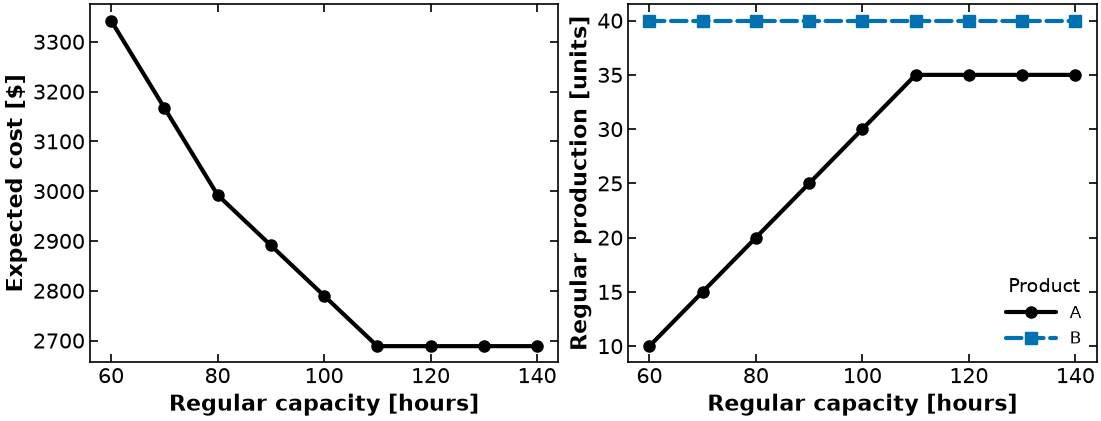

,expected cost,A,B
capacity,,,
60,3342.50,10.0,40.0
70,3167.50,15.0,40.0
80,2992.50,20.0,40.0
90,2891.25,25.0,40.0
100,2790.00,30.0,40.0
110,2688.75,35.0,40.0
120,2688.75,35.0,40.0
130,2688.75,35.0,40.0
140,2688.75,35.0,40.0


In [7]:
capacity_rows = []
for capacity in range(60, 141, 10):
    model = solve(build_model(capacity=capacity))
    capacity_rows.append(
        {
            "capacity": capacity,
            "expected cost": pyo.value(model.objective),
            **regular_plan(model),
        }
    )
capacity_results = pd.DataFrame(capacity_rows).set_index("capacity")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
capacity_results["expected cost"].plot(ax=axes[0], marker="o", color="black")
for product, marker, line in [("A", "o", "-"), ("B", "s", "--")]:
    axes[1].plot(
        capacity_results.index,
        capacity_results[product],
        marker=marker,
        linestyle=line,
        label=product,
    )
axes[1].legend(title="Product")
axes[0].set(xlabel="Regular capacity [hours]", ylabel="Expected cost [$]")
axes[1].set(xlabel="Regular capacity [hours]", ylabel="Regular production [units]")
plt.show()
capacity_results.round(2)

## Interpret

1. Which decisions are made before demand is known?
2. In which scenarios does the plan use emergency production or disposal?
3. Why do the subtraction orders reverse for profit maximization while VSS and EVPI remain nonnegative?
4. Which product receives scarce regular capacity first, and which tradeoff explains that choice?
5. What modeling detail would you add before using this plan in practice?

## Mean and tail cost

The loss-oriented CVaR epigraph follows Rockafellar and Uryasev (2000, 2002). At confidence 0.9, use the worst 10% of probability mass. With three scenario probabilities 0.25, 0.5, 0.25, this equals the largest scenario cost. The risk weight changes the objective, not the uncertainty distribution.


In [8]:
def add_cost_cvar(m, confidence=0.9, risk_weight=0.5):
    """Blend expected cost and upper-tail cost CVaR, both in dollars."""
    if not 0 < confidence < 1 or not 0 <= risk_weight <= 1:
        raise ValueError("Require 0 < confidence < 1 and 0 <= weight <= 1")
    m.threshold = pyo.Var(domain=pyo.Reals)
    m.excess = pyo.Var(m.S, domain=pyo.NonNegativeReals)

    # Include regular cost in every realized TOTAL cost.
    @m.Constraint(m.S)
    def tail(b, s):
        return b.excess[s] >= b.regular_cost + b.scenario[s].recourse_cost - b.threshold

    # Probability weights need not be equal; the denominator is tail mass.
    m.cvar_cost = pyo.Expression(
        expr=m.threshold
        + sum(m.probability[s] * m.excess[s] for s in m.S) / (1 - confidence)
    )
    m.objective.deactivate()  # Only the blended objective remains active.
    m.risk_objective = pyo.Objective(
        expr=(1 - risk_weight) * (m.regular_cost + m.expected_recourse_cost)
        + risk_weight * m.cvar_cost,
        sense=pyo.minimize,
    )
    return m

In [9]:
import numpy as np

risk_rows = []
for weight in [0.0, 0.5, 1.0]:
    model = solve(add_cost_cvar(build_model(), risk_weight=weight))
    costs = np.array(
        [
            pyo.value(model.regular_cost + model.scenario[s].recourse_cost)
            for s in model.S
        ]
    )
    probabilities = np.array([PROBABILITY[s] for s in model.S])
    # Evaluate risk independently at all loss breakpoints. This also works
    # at weight zero, when the model's threshold/excess need not be tight.
    cvar = min(v + probabilities @ np.maximum(costs - v, 0) / 0.1 for v in costs)
    risk_rows.append(
        {
            "weight": weight,
            **regular_plan(model),
            # Re-solve with the plan fixed and EXPECTED cost as the objective.
            # Reading the mean off `costs` would be reading scenarios the
            # risk objective never priced -- see the section below.
            "mean cost": fixed_plan_cost(regular_plan(model)),
            "CVaR(0.9)": cvar,
        }
    )
print(pd.DataFrame(risk_rows).set_index("weight").round(2).to_string())

# A discrete atom at VaR contributes only the tail mass still needed.
losses = np.array([0.0, 10.0, 100.0])
probabilities = np.array([0.8, 0.15, 0.05])
assert (
    abs(min(v + probabilities @ np.maximum(losses - v, 0) / 0.1 for v in losses) - 55.0)
    < 1e-10
)

           A     B  mean cost  CVaR(0.9)
weight                                  
0.0     30.0  40.0     2790.0     5320.0
0.5     30.0  40.0     2790.0     5320.0
1.0     15.0  70.0     3655.0     4735.0


## Which scenarios did the objective actually price?

The `weight = 1.0` row above is a **pure CVaR** objective. With scenario
probabilities $0.25$, $0.5$, $0.25$ and confidence $0.9$, the tail mass $0.1$ is
smaller than any single scenario's probability, so $\mathrm{CVaR}_{0.9}$ is just
the **largest** scenario cost.

That means the objective references the `high` scenario **and nothing else**. The
`low` and `likely` recourse variables appear nowhere in it, so the solver is free
to return any feasible values for them.

The balance $x_p + e_{sp} - w_{sp} = d_{sp}$ fixes $e_{sp} - w_{sp}$, but not
$e_{sp}$ and $w_{sp}$ separately: for any $t \ge 0$, emergency $=d-x+t$ with
disposal $=t$ is feasible and costs more. In an unpriced scenario every such $t$
is equally optimal.


In [10]:
# Is the multiplicity real, or does the constraint happen to pin it down?
# Pin the CVaR objective at its optimum, then MAXIMIZE the reported mean cost.
# Any answer above the reported one is an equally optimal solution that would
# have printed a different number in the table above.
pure_cvar = solve(add_cost_cvar(build_model(), risk_weight=1.0))
cvar_optimum = float(pyo.value(pure_cvar.cvar_cost))
reported_mean = sum(
    PROBABILITY[s] * pyo.value(pure_cvar.regular_cost + pure_cvar.scenario[s].recourse_cost)
    for s in pure_cvar.S
)

probe = add_cost_cvar(build_model(), risk_weight=1.0)
# Stay on the set of CVaR-optimal solutions ...
probe.stay_optimal = pyo.Constraint(expr=probe.cvar_cost <= cvar_optimum + 1e-9)
probe.risk_objective.deactivate()
# ... and among those, find the WORST mean cost the solver could have reported.
probe.worst_reported_mean = pyo.Objective(
    expr=sum(
        probe.probability[s] * (probe.regular_cost + probe.scenario[s].recourse_cost)
        for s in probe.S
    ),
    sense=pyo.maximize,
)
solve(probe)

print(f"CVaR(0.9) optimum, pinned          : {cvar_optimum:,.2f}")
print(f"mean cost this solver reported     : {reported_mean:,.2f}")
print(f"mean cost an equally optimal answer: {pyo.value(probe.worst_reported_mean):,.2f}")
print(f"spread between the two             : "
      f"{pyo.value(probe.worst_reported_mean) - reported_mean:,.2f}")
print()
print("plan, both solutions :", regular_plan(pure_cvar), regular_plan(probe))
print("per-scenario costs, as reported     :",
      [round(pyo.value(pure_cvar.regular_cost + pure_cvar.scenario[s].recourse_cost), 1)
       for s in pure_cvar.S])
print("per-scenario costs, the other optimum:",
      [round(pyo.value(probe.regular_cost + probe.scenario[s].recourse_cost), 1)
       for s in probe.S])

CVaR(0.9) optimum, pinned          : 4,735.00
mean cost this solver reported     : 3,655.00
mean cost an equally optimal answer: 4,735.00
spread between the two             : 1,080.00

plan, both solutions : {'A': 15.0, 'B': 70.0} {'A': 14.999999999990287, 'B': 70.00000000001943}
per-scenario costs, as reported     : [2805.0, 3540.0, 4735.0]
per-scenario costs, the other optimum: [4735.0, 4735.0, 4735.0]


### The number was right by luck, not by construction

**First, the two plans printed above.** The probe reports
`{'A': 14.999999999990287, 'B': 70.00000000001943}` where the original solve
reports `{'A': 15.0, 'B': 70.0}`. That difference is about $10^{-11}$ on a
quantity of order $10$, which is consistent with an **LP tolerance artifact**
introduced by the `stay_optimal` constraint --- pinning an objective at its own
optimum leaves the solver working right at the edge of feasibility, and it stops
a hair inside. It is not evidence of a second, distinct plan. So read *"same
plan"* below as **the same plan to solver tolerance**, which is the only sense in
which a floating-point solver can report sameness at all.

It is left unrounded deliberately. A notebook whose lesson is *"you cannot tell
from the output whether it is wrong"* is the last place to tidy away a number
that looks odd.


Same plan. Same objective value. A **\$1,080 spread** in the mean cost that gets
printed, decided entirely by which optimal vertex the simplex method happened to
stop at.

That is why the table above no longer reads the mean off the risk solve. It calls
`fixed_plan_cost(regular_plan(model))`, which fixes the plan and re-solves with
**expected** cost as the objective — pricing every scenario. The printed number is
unchanged; it is now unchanged *for a reason*.

**Compare with the farmer.** The same defect appears in
[Stochastic Programming](./SP.ipynb), and there it is **not** subtle: a pure-CVaR
solve reports an expected profit of \$59,950 when the plan's true expected profit
is \$86,600, a \$26,650 error visible the moment you look.

| | Farmer | This notebook |
| --- | --- | --- |
| Reported number | **wrong** by \$26,650 | **right**, at \$3,655 |
| Visible on inspection? | yes | **no** |
| Multiplicity present? | yes | **yes** |

🔴 **This is the lesson, and it needs both examples to make it.** The reason to
distrust recourse the objective never priced is *not* that it is usually wrong.
It is that **you cannot tell from the output whether it is wrong.** The farmer
shows you the failure; this notebook shows you that the failure can hide.

And it is not about CVaR. A minimax objective prices only the worst scenario and
fails the same way; so does a chance constraint that binds on a subset. **Any
objective that prices only part of the scenario set leaves the rest
unconstrained.**


## Sources

* Birge and Louveaux (2011), 2nd ed., §§2.4, 4.1–4.3, pp. 59–65, 163–166: recourse and information values.
* Rockafellar and Uryasev (2000), *Optimization of Conditional Value-at-Risk*.
* Rockafellar and Uryasev (2002), *Conditional Value-at-Risk for General Loss Distributions*, [author preprint](https://sites.math.washington.edu/~rtr/papers/rtr187-CVaR2.pdf).
* [Pyomo Block documentation](https://pyomo.readthedocs.io/en/stable/api/pyomo.core.base.block.Block.html).
